# Module 7 — ANOVA, Rank-Based Tests & Categorical Data

**Statistics Deep Dive · Notebook 7 of 13**

Module 6 compared *two* groups with a numeric outcome. Real questions are rarely that tidy: four fertilisers, three marketing channels crossed with three discount levels, star ratings that are not really numbers, counts in a contingency table. This module extends the testing toolbox to all of these.

### 🎯 Learning goals
After this module you can …
1. explain ANOVA as a **signal-to-noise ratio** of variances and build the ANOVA table by hand,
2. follow up a significant ANOVA with **Tukey's HSD** and check the assumptions,
3. analyse two factors at once and interpret an **interaction**,
4. choose and interpret **rank-based tests** (Mann–Whitney, Wilcoxon, Kruskal–Wallis),
5. test categorical data with **$\chi^2$ goodness-of-fit** and **independence** tests and read residuals,
6. analyse 2×2 tables with **Fisher's exact test, relative risk and odds ratio**.

### 🗺️ Contents
1. The idea of ANOVA · 2. Decomposing variation · 3. Assumptions & effect size · 4. Post-hoc comparisons · 5. Two-way ANOVA & interactions · 6. Rank-based tests · 7. $\chi^2$ goodness of fit · 8. $\chi^2$ test of independence · 9. 2×2 tables: risk, odds, Fisher · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

---
## 1. The idea of ANOVA — comparing means by comparing variances

With $k$ groups you could run all $k(k-1)/2$ pairwise $t$-tests — but with 5 groups that is 10 tests, and the chance of at least one false alarm rises to about $1-0.95^{10} \approx 40\,\%$. **Analysis of variance (ANOVA)** asks one global question first:

$$H_0: \mu_1 = \mu_2 = \dots = \mu_k \qquad\text{vs.}\qquad H_1: \text{at least one mean differs.}$$

The trick: if $H_0$ is true, the group means should scatter only as much as chance allows given the noise *inside* the groups. So we compare two variance estimates:

$$F = \frac{\text{variation between group means (signal)}}{\text{variation within groups (noise)}}$$

> 🤔 **Predict first:** both panels below have *identical* group means (20, 23, 26). In which panel will ANOVA find a difference — and why?

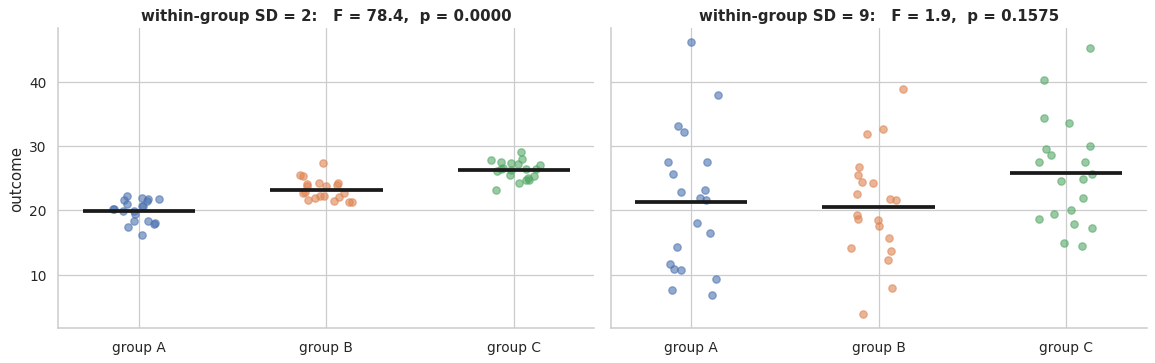

In [2]:
means = [20, 23, 26]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, sd in zip(axes, [2, 9]):
    groups = [rng.normal(m, sd, 20) for m in means]
    F, p = stats.f_oneway(*groups)
    for i, y in enumerate(groups):
        ax.scatter(i + rng.uniform(-.15, .15, y.size), y, color=C[i], alpha=.6, s=35)
        ax.hlines(y.mean(), i - .3, i + .3, color="k", lw=3)
    ax.set(xticks=range(3), xticklabels=["group A", "group B", "group C"], title=f"within-group SD = {sd}:   F = {F:.1f},  p = {p:.4f}")
axes[0].set_ylabel("outcome")
plt.tight_layout(); plt.show()

**Reading the figure.** The black bars (group means) are at almost the same heights in both panels. On the left the points hug their means — the differences between groups are large *relative to the noise*, $F$ is huge. On the right the same differences drown in the within-group scatter. **ANOVA does not look at the means alone; it looks at the means relative to the noise.**

---
## 2. Decomposing variation — the ANOVA table by hand

Every observation's deviation from the grand mean $\bar y$ splits into two parts: $\;(y_{ij}-\bar y) = (\bar y_j - \bar y) + (y_{ij}-\bar y_j)$. Squaring and summing (the cross terms vanish) gives the fundamental identity

$$\underbrace{\sum_{j}\sum_{i}(y_{ij}-\bar y)^2}_{SS_{total}} \;=\; \underbrace{\sum_j n_j(\bar y_j-\bar y)^2}_{SS_{between}} \;+\; \underbrace{\sum_j\sum_i (y_{ij}-\bar y_j)^2}_{SS_{within}}$$

Dividing by the degrees of freedom gives *mean squares*; their ratio is $F = \dfrac{SS_B/(k-1)}{SS_W/(N-k)} \sim F_{k-1,\,N-k}$ under $H_0$.

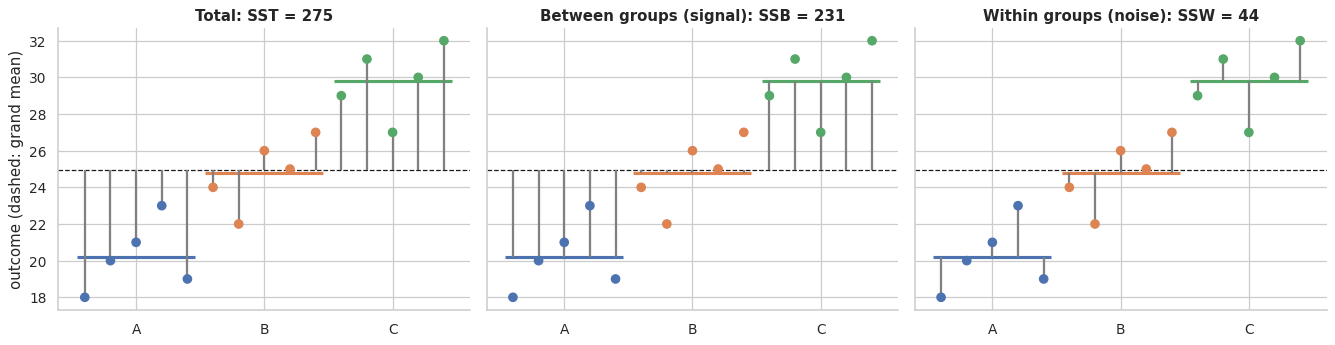

               SS  df        MS        F    p
between  230.5333   2  115.2667  31.1532  0.0
within    44.4000  12    3.7000      NaN  NaN
total    274.9333  14       NaN      NaN  NaN

scipy check: F = 31.1532, p = 0.000018


In [3]:
groups = {"A": np.array([18, 20, 21, 23, 19.]), "B": np.array([24, 22, 26, 25, 27.]), "C": np.array([29, 31, 27, 30, 32.])}
y = np.concatenate(list(groups.values())); grand = y.mean(); xpos = np.arange(y.size)
gm = np.repeat([v.mean() for v in groups.values()], 5)                       # group mean, repeated for each observation
SST, SSB, SSW = ((y - grand) ** 2).sum(), ((gm - grand) ** 2).sum(), ((y - gm) ** 2).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
panels = [(y, np.full_like(y, grand), f"Total: SST = {SST:.0f}"), (gm, np.full_like(y, grand), f"Between groups (signal): SSB = {SSB:.0f}"),
          (y, gm, f"Within groups (noise): SSW = {SSW:.0f}")]
for ax, (start, end, title) in zip(axes, panels):
    ax.axhline(grand, color="k", ls="--", lw=1)
    for j in range(3):
        ax.hlines(gm[j * 5], j * 5 - .3, j * 5 + 4.3, color=C[j], lw=2.5)
    ax.vlines(xpos, end, start, color="grey", lw=1.8)
    ax.scatter(xpos, y, color=[C[j] for j in np.repeat(range(3), 5)], zorder=3, s=45)
    ax.set(title=title, xticks=[2, 7, 12], xticklabels=list(groups))
axes[0].set_ylabel("outcome (dashed: grand mean)")
plt.tight_layout(); plt.show()

k, N = 3, y.size
F = (SSB / (k - 1)) / (SSW / (N - k))
print(pd.DataFrame({"SS": [SSB, SSW, SST], "df": [k - 1, N - k, N - 1], "MS": [SSB / (k - 1), SSW / (N - k), np.nan],
                    "F": [F, np.nan, np.nan], "p": [stats.f.sf(F, k - 1, N - k), np.nan, np.nan]}, index=["between", "within", "total"]).round(4))
F_scipy, p_scipy = stats.f_oneway(*groups.values()); print(f"\nscipy check: F = {F_scipy:.4f}, p = {p_scipy:.6f}")

**Reading the figure.** The grey lines are the deviations being squared. *Left:* every point to the grand mean. *Middle:* what would remain if every observation sat exactly on its group mean — pure group effect. *Right:* what remains after removing the group means — pure noise. $274.9 = 230.5 + 44.4$: the groups explain 84 % of the total variation ($\eta^2 = SS_B/SS_T$). For $k=2$ groups, ANOVA and the pooled $t$-test are identical ($F = t^2$).

---
## 3. Assumptions & effect size

| Assumption | How to check | If violated |
|---|---|---|
| independent observations | study design! | mixed models / repeated-measures ANOVA |
| roughly normal **residuals** | Q–Q plot of residuals, Shapiro–Wilk | robust for moderate $n$; otherwise Kruskal–Wallis or permutation |
| equal variances in all groups | boxplots, Levene's test | **Welch's ANOVA** (the default choice of many statisticians), or transform the outcome |

ANOVA is fairly robust to non-normality, less so to unequal variances combined with unequal group sizes (exactly like Student's $t$-test in Module 6).

**Effect size.** $\eta^2 = SS_B/SS_T$ is the share of variance explained by group membership (the $R^2$ of Module 9). It is biased upwards in small samples; $\omega^2$ is the less biased cousin.

A significant $F$ only says *"not all means are equal"* — it does not say **which** ones differ. That is the job of post-hoc tests.

---
## 4. Post-hoc comparisons — Tukey's HSD

Tukey's *honestly significant difference* compares all pairs of means while keeping the **family-wise** error rate at $\alpha$. It uses the distribution of the *largest* difference among $k$ means (studentised range), so its intervals are wider than ordinary $t$-intervals — the fair price for looking at many pairs.

global ANOVA: F = 9.14, p = 0.000051
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
control diet A   0.7517 0.6153 -0.8763 2.3797  False
control diet B   2.6259 0.0004  0.9979  4.254   True
control diet C   2.5518 0.0006  0.9238 4.1798   True
 diet A diet B   1.8742 0.0179  0.2462 3.5022   True
 diet A diet C   1.8001 0.0247  0.1721 3.4281   True
 diet B diet C  -0.0741 0.9994 -1.7022 1.5539  False
----------------------------------------------------


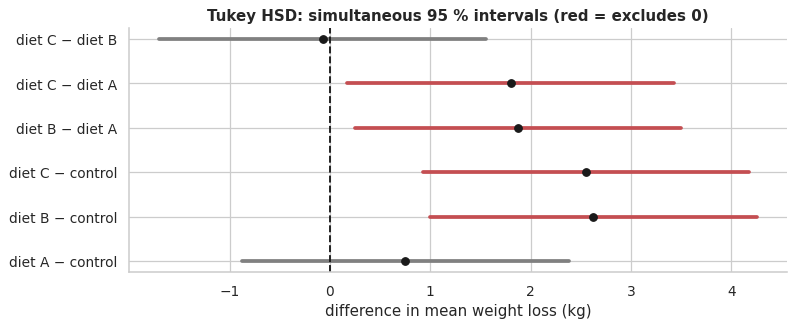

In [4]:
diet_means = {"control": 3.0, "diet A": 3.4, "diet B": 5.1, "diet C": 5.4}                 # true mean weight loss (kg)
diet = pd.DataFrame([(d, v) for d, m in diet_means.items() for v in rng.normal(m, 1.6, 15)], columns=["diet", "loss_kg"])
F, p = stats.f_oneway(*[g.loss_kg for _, g in diet.groupby("diet")]); print(f"global ANOVA: F = {F:.2f}, p = {p:.6f}")
tk = pairwise_tukeyhsd(diet.loss_kg, diet.diet)
print(tk.summary())

i, j = np.triu_indices(len(tk.groupsunique), 1)
labels = [f"{tk.groupsunique[b]} − {tk.groupsunique[a]}" for a, b in zip(i, j)]
fig, ax = plt.subplots(figsize=(9, 3.8))
for r, (mdiff, (lo, hi), rej) in enumerate(zip(tk.meandiffs, tk.confint, tk.reject)):
    ax.plot([lo, hi], [r, r], color=C[3] if rej else "grey", lw=3); ax.scatter(mdiff, r, color="k", zorder=3)
ax.axvline(0, color="k", ls="--"); ax.set(yticks=range(len(labels)), yticklabels=labels, xlabel="difference in mean weight loss (kg)",
                                          title="Tukey HSD: simultaneous 95 % intervals (red = excludes 0)")
plt.tight_layout(); plt.show()

**Reading the figure.** Intervals that exclude zero (red) mark pairs that differ. Typical pattern: the diets fall into two clusters — {control, A} and {B, C} — with clear differences *between* clusters and none *within*. Report it that way rather than as six separate verdicts.

---
## 5. Two-way ANOVA — two factors and their interaction

With two factors we can estimate two **main effects** *and* their **interaction**: does the effect of factor A *depend on* the level of factor B? In an interaction plot, **parallel lines = no interaction**; non-parallel lines = interaction.

$$y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

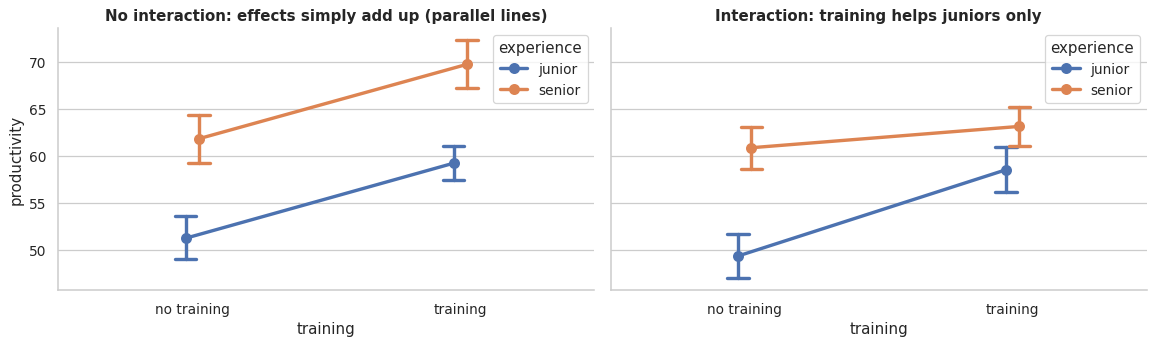

                        sum_sq    df        F  PR(>F)
training              816.4206   1.0  24.1168  0.0000
experience           1623.4286   1.0  47.9556  0.0000
training:experience   297.4271   1.0   8.7859  0.0038
Residual             3249.8601  96.0      NaN     NaN


In [5]:
def simulate(interaction):
    rows = []
    for a, A in enumerate(["no training", "training"]):
        for b, B in enumerate(["junior", "senior"]):
            mu = 50 + 8 * a + 12 * b - (8 * a * b if interaction else 0)      # with interaction: training does not help seniors
            rows += [(A, B, v) for v in rng.normal(mu, 6, 25)]
    return pd.DataFrame(rows, columns=["training", "experience", "productivity"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, inter, title in zip(axes, [False, True], ["No interaction: effects simply add up (parallel lines)", "Interaction: training helps juniors only"]):
    d = simulate(inter)
    sns.pointplot(data=d, x="training", y="productivity", hue="experience", ax=ax, dodge=True, palette=[C[0], C[1]], capsize=.08)
    ax.set_title(title)
plt.tight_layout(); plt.show()

model = smf.ols("productivity ~ training * experience", data=d).fit()          # d = the interaction scenario
print(sm.stats.anova_lm(model, typ=2).round(4))

**Reading the output.** The row `training:experience` tests the interaction. **If the interaction is significant, do not interpret the main effects in isolation** — "the effect of training" is no longer one number; report it separately per experience level (*simple effects*). The ANOVA here is just a linear regression with categorical predictors — we will meet it again in Module 10.

> 🛠️ **Formula note.** In a statsmodels formula, `a * b` means *both main effects plus their interaction*. Text columns are treated as categorical automatically. For a numerically coded factor you would normally write `C(factor)` — but in this course the name `C` is already taken by our colour palette, so convert such columns with `.astype(str)` instead.

---
## 6. Rank-based (non-parametric) tests

Replace the data by their **ranks** and most distributional worries disappear: ranks ignore *how far* an outlier is away, and they are the natural scale for **ordinal** data (star ratings, pain scores, school grades).

| Design | Parametric test | Rank-based counterpart | What it tests |
|---|---|---|---|
| 2 independent groups | Welch $t$ | **Mann–Whitney $U$** (Wilcoxon rank-sum) | $P(X>Y) = 0.5$? — does one group tend to have larger values? |
| 2 paired measurements | paired $t$ | **Wilcoxon signed-rank** | are the differences symmetric around 0? |
| $k$ independent groups | one-way ANOVA | **Kruskal–Wallis** | do all groups have the same distribution? |

A useful effect size for Mann–Whitney is the **probability of superiority** $\;U/(n_1n_2) = P(X>Y)+\tfrac12P(X=Y)$.

> ⚠️ Rank tests compare *distributions*, not means. They are a test of medians only if the two distributions have the same shape.

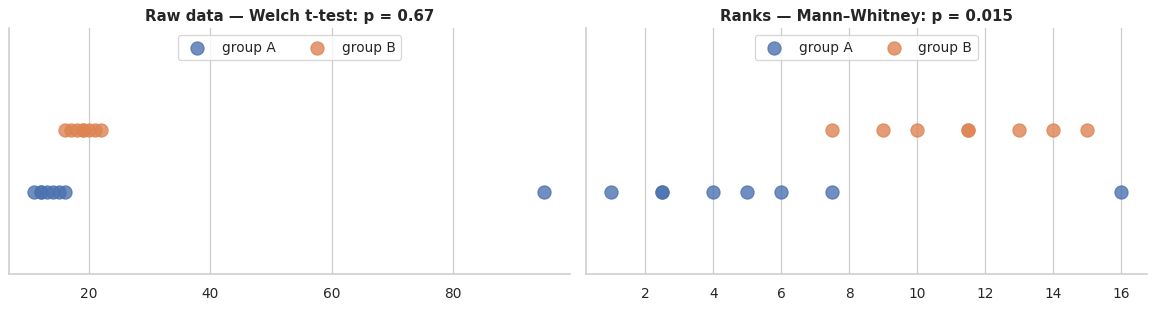

In [6]:
a = np.array([12, 15, 11, 14, 13, 16, 12, 95.])                    # one wild outlier (a typo? a VIP customer?)
b = np.array([17, 19, 16, 21, 18, 20, 22, 19.])
ranks = stats.rankdata(np.concatenate([a, b])); ra, rb = ranks[:a.size], ranks[a.size:]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, (va, vb), title in [(a1, (a, b), f"Raw data — Welch t-test: p = {stats.ttest_ind(a, b, equal_var=False).pvalue:.2f}"),
                            (a2, (ra, rb), f"Ranks — Mann–Whitney: p = {stats.mannwhitneyu(a, b).pvalue:.3f}")]:
    ax.scatter(va, np.zeros_like(va), s=110, color=C[0], alpha=.8, label="group A"); ax.scatter(vb, np.ones_like(vb) * .3, s=110, color=C[1], alpha=.8, label="group B")
    ax.set(yticks=[], ylim=(-.4, .8), title=title); ax.legend(loc="upper center", ncol=2)
plt.tight_layout(); plt.show()

**Reading the figure.** Seven of eight A-values are below *all* B-values, yet the outlier inflates A's mean and standard deviation so much that the $t$-test sees nothing. On the rank scale the outlier is simply "rank 16" and the pattern is obvious.

### 6.1 What do you pay for this robustness?
Simulation: power of Welch's $t$-test vs. Mann–Whitney for a location shift, $n=25$ per group, under three populations.

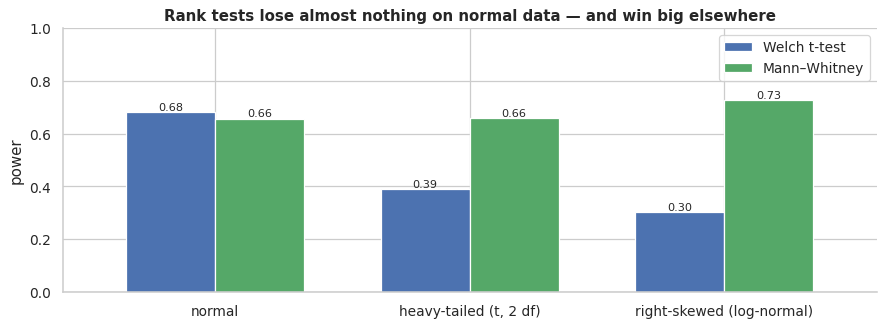

In [7]:
def power(draw, shift, R=4000, n=25):
    x, y = draw((R, n)), draw((R, n)) + shift
    return {"Welch t-test": (stats.ttest_ind(x, y, axis=1, equal_var=False).pvalue < .05).mean(),
            "Mann–Whitney": (stats.mannwhitneyu(x, y, axis=1).pvalue < .05).mean()}

pw = pd.DataFrame({"normal": power(lambda s: rng.normal(0, 1, s), .7),
                   "heavy-tailed (t, 2 df)": power(lambda s: rng.standard_t(2, s), 1.0),
                   "right-skewed (log-normal)": power(lambda s: rng.lognormal(0, 1, s), .7)}).T
ax = pw.plot.bar(figsize=(10, 3.8), color=[C[0], C[2]], rot=0, width=.7)
ax.set(ylabel="power", ylim=(0, 1), title="Rank tests lose almost nothing on normal data — and win big elsewhere")
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f", fontsize=9)
plt.tight_layout(); plt.show()

**Reading the figure.** On perfectly normal data Mann–Whitney has ≈ 95 % of the $t$-test's efficiency. With heavy tails or skew it is far more powerful. For small, messy samples a rank test is rarely a bad choice — but remember that it answers a slightly different question (stochastic dominance, not the difference in means), and gives no estimate in the original units.

---
## 7. $\chi^2$ goodness-of-fit test — do counts follow a claimed distribution?

For categorical data we compare **observed counts** $O_i$ with the counts **expected** under $H_0$, $E_i = n\,p_i$:

$$\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i} \;\sim\; \chi^2_{k-1}\quad\text{(approximately, if all } E_i \gtrsim 5).$$

Each term is a squared standardised deviation — large deviations in cells where we *expected many* observations count less than the same deviation in a sparse cell.

**Example.** An IT help desk staffs equally on all weekdays. Are tickets really spread evenly over the week?

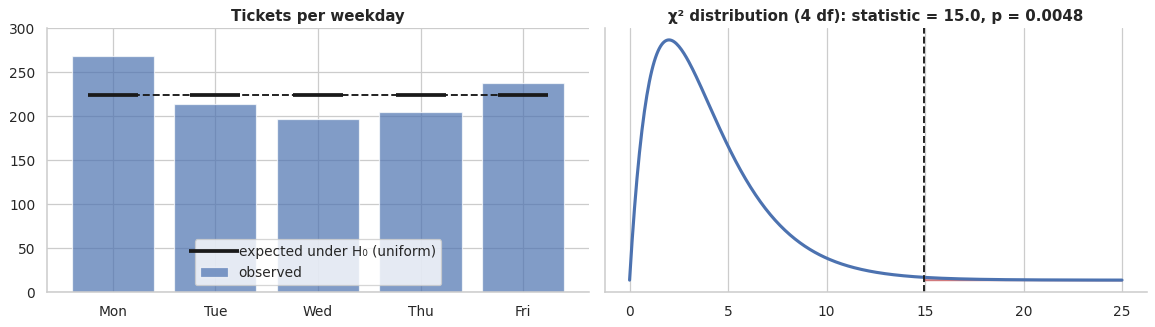

contribution of each day to χ²: {'Mon': 8.6, 'Tue': 0.4, 'Wed': 3.5, 'Thu': 1.6, 'Fri': 0.8}


In [8]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]; observed = np.array([268, 214, 196, 205, 237])
expected = np.full(5, observed.sum() / 5)
chi2, p = stats.chisquare(observed, expected)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
a1.bar(days, observed, color=C[0], alpha=.7, label="observed"); a1.plot(days, expected, "k_--", ms=40, mew=3, label="expected under H₀ (uniform)")
a1.set(title="Tickets per weekday", ylim=(0, 300)); a1.legend(loc="lower center")
x = np.linspace(0, 25, 400); a2.plot(x, stats.chi2.pdf(x, 4), color=C[0], lw=2.5); a2.fill_between(x, stats.chi2.pdf(x, 4), where=x >= chi2, color=C[3], alpha=.6)
a2.axvline(chi2, color="k", ls="--"); a2.set(title=f"χ² distribution (4 df): statistic = {chi2:.1f}, p = {p:.4f}", yticks=[])
plt.tight_layout(); plt.show()
print("contribution of each day to χ²:", pd.Series((observed - expected) ** 2 / expected, index=days).round(1).to_dict())

---
## 8. $\chi^2$ test of independence — are two categorical variables related?

For a contingency table, independence means $P(\text{row } i \text{ and column } j) = P(\text{row } i)\,P(\text{column } j)$, so the expected count is

$$E_{ij} = \frac{(\text{row total}_i)\,(\text{column total}_j)}{n}, \qquad \chi^2 = \sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}} \sim \chi^2_{(r-1)(c-1)}.$$

* **Where** is the association? Look at the **standardised residuals** $(O-E)/\sqrt E$; values beyond ±2 deserve attention.
* **How strong** is it? **Cramér's $V$** $=\sqrt{\chi^2/(n\,(\min(r,c)-1))}\in[0,1]$. With large $n$, a tiny association can be "highly significant".

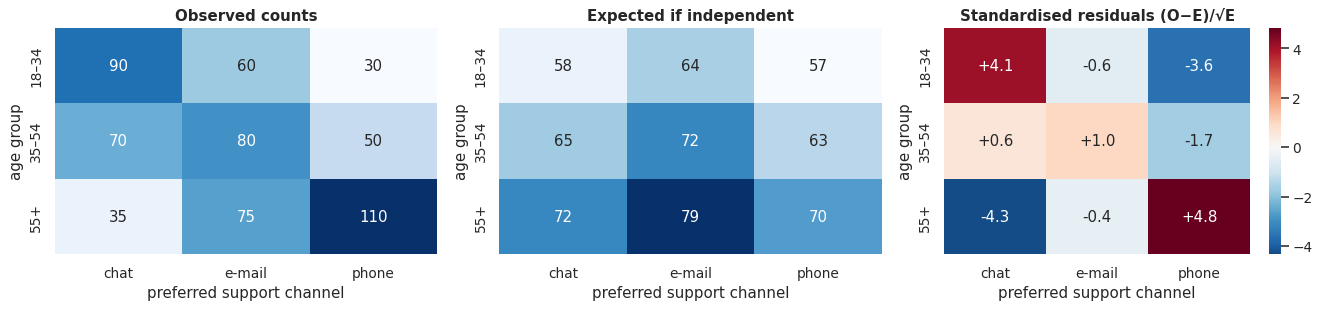

chi2 = 76.4, df = 4, p = 1.01e-15, Cramér's V = 0.25


In [9]:
obs = pd.DataFrame([[90, 60, 30], [70, 80, 50], [35, 75, 110]], index=["18–34", "35–54", "55+"], columns=["chat", "e-mail", "phone"])
chi2, p, dof, exp = stats.chi2_contingency(obs)
resid = (obs - exp) / np.sqrt(exp)
V = np.sqrt(chi2 / (obs.values.sum() * (min(obs.shape) - 1)))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sns.heatmap(obs, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0]); axes[0].set_title("Observed counts")
sns.heatmap(pd.DataFrame(exp, obs.index, obs.columns), annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[1]); axes[1].set_title("Expected if independent")
sns.heatmap(resid, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=axes[2]); axes[2].set_title("Standardised residuals (O−E)/√E")
for ax in axes: ax.set(xlabel="preferred support channel", ylabel="age group")
plt.tight_layout(); plt.show()
print(f"chi2 = {chi2:.1f}, df = {dof}, p = {p:.2e}, Cramér's V = {V:.2f}")

**Reading the figure.** The residual map tells the story the p-value cannot: young customers choose chat far more often than independence would predict (+), older customers choose the phone (+) and avoid chat (−). Cramér's $V \approx 0.25$ is a moderate association.

---
## 9. 2×2 tables — risk difference, relative risk, odds ratio & Fisher's exact test

| | event | no event | risk |
|---|---|---|---|
| **exposed / treated** | $a$ | $b$ | $p_1 = a/(a+b)$ |
| **control** | $c$ | $d$ | $p_2 = c/(c+d)$ |

| Measure | Formula | Reading |
|---|---|---|
| **Risk difference** (RD) | $p_1-p_2$ | absolute effect; $1/\lvert RD\rvert$ = *number needed to treat* (NNT) |
| **Relative risk** (RR) | $p_1/p_2$ | "treated patients have RR times the risk" |
| **Odds ratio** (OR) | $\dfrac{a/b}{c/d} = \dfrac{ad}{bc}$ | the only valid measure in case–control studies; natural scale of logistic regression (Module 11); ≈ RR when the event is rare |

Confidence intervals are built on the log scale: $\;\operatorname{SE}(\ln RR)=\sqrt{\tfrac1a-\tfrac1{a+b}+\tfrac1c-\tfrac1{c+d}}$, $\;\operatorname{SE}(\ln OR)=\sqrt{\tfrac1a+\tfrac1b+\tfrac1c+\tfrac1d}$.

For small tables (any expected count < 5) use **Fisher's exact test**, which enumerates all tables with the same margins instead of relying on the $\chi^2$ approximation.

**Example — a classic of preventive medicine.** In the Physicians' Health Study (as reported in Agresti's *Categorical Data Analysis*), 104 of 11,037 physicians taking aspirin and 189 of 11,034 taking placebo suffered a heart attack.

In [10]:
def two_by_two(a, b, c, d):
    p1, p2 = a / (a + b), c / (c + d)
    rr, se_rr = p1 / p2, np.sqrt(1 / a - 1 / (a + b) + 1 / c - 1 / (c + d))
    orr, se_or = (a * d) / (b * c), np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    ci = lambda est, se: (est * np.exp(-1.96 * se), est * np.exp(1.96 * se))
    return {"risk treated": p1, "risk control": p2, "RD": p1 - p2, "NNT": 1 / abs(p1 - p2), "RR": rr, "RR 95% CI": ci(rr, se_rr), "OR": orr, "OR 95% CI": ci(orr, se_or)}

r = two_by_two(104, 11_037 - 104, 189, 11_034 - 189)
for key, val in r.items():
    print(f"{key:13s}: " + (f"{val[0]:.3f} – {val[1]:.3f}" if isinstance(val, tuple) else f"{val:.4f}"))
print("Fisher's exact test: p =", f"{stats.fisher_exact([[104, 10_933], [189, 10_845]])[1]:.2e}")

risk treated : 0.0094
risk control : 0.0171
RD           : -0.0077
NNT          : 129.7686
RR           : 0.5501
RR 95% CI    : 0.434 – 0.698
OR           : 0.5458
OR 95% CI    : 0.429 – 0.694
Fisher's exact test: p = 5.03e-07


**Reading the output.** Aspirin cut the *relative* risk by about 45 % (RR ≈ 0.55) — impressive. The *absolute* risk reduction is 0.77 percentage points: about **130 physicians must take aspirin for five years to prevent one heart attack** (NNT). Both statements are true; honest communication reports both. Because the event is rare, OR ≈ RR.

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 7.1 — *One-way ANOVA & Tukey HSD*: Which fertiliser blend should the cooperative buy? (Agriculture)

An agricultural cooperative tests three fertiliser blends against a control on 40 comparable wheat plots (10 per treatment, randomly assigned). Blend C is 20 % cheaper than blend B.

**Tasks**
1. Plot the yields per treatment.
2. Run a one-way ANOVA and compute $\eta^2$.
3. Check the assumptions (Levene's test; normality of the residuals).
4. Run Tukey's HSD. Which treatments differ?
5. Which blend do you recommend, and why?

In [11]:
g = np.random.default_rng(737)
true_means = {"control": 5.2, "blend A": 5.5, "blend B": 6.3, "blend C": 6.1}                 # t/ha — unknown to the analyst
wheat = pd.DataFrame([(b, y) for b, mu in true_means.items() for y in g.normal(mu, .55, 10).round(2)], columns=["fertiliser", "yield_t_ha"])
wheat.groupby("fertiliser", sort=False).yield_t_ha.agg(["mean", "std"]).round(2)

,mean,std
fertiliser,,
control,5.27,0.53
blend A,5.62,0.64
blend B,6.51,0.38
blend C,6.26,0.65


In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

### ✍️ Exercise 7.2 — *Two-way ANOVA & interaction*: Where does the discount pay off? (Marketing)

A retailer ran a 3 × 3 campaign experiment: three **channels** (e-mail, social, search) crossed with three **discount levels** (0 %, 10 %, 20 %), 30 customers per cell. Outcome: revenue per customer (€).

**Tasks**
1. Draw an interaction plot (discount on the x-axis, one line per channel).
2. Fit the two-way ANOVA with interaction and print the type-II table.
3. Is there an interaction? What does it mean in business terms?
4. Compute the cell means. For which channel does the step from 10 % to 20 % discount bring the most?

In [13]:
g = np.random.default_rng(702)
rows = []
for ch, base in {"e-mail": 40, "social": 34, "search": 46}.items():
    for disc, lift in {"0 %": 0, "10 %": 6, "20 %": 9}.items():
        extra = 8 if (ch == "social" and disc == "20 %") else 0
        rows += [(ch, disc, v) for v in g.normal(base + lift + extra, 9, 30).round(1)]
camp = pd.DataFrame(rows, columns=["channel", "discount", "revenue"])
camp.head()

,channel,discount,revenue
0,e-mail,0 %,31.6
1,e-mail,0 %,31.5
2,e-mail,0 %,50.8
3,e-mail,0 %,21.6
4,e-mail,0 %,46.5


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

### ✍️ Exercise 7.3 — *Mann–Whitney U*: Did the app redesign improve ratings? (Product analytics)

Star ratings (1–5) were collected for the old and the redesigned version of a mobile app. Ratings are **ordinal** — the distance between 1★ and 2★ need not equal the distance between 4★ and 5★ — so comparing means is questionable.

**Tasks**
1. Plot the two rating distributions as percentages.
2. Run a Mann–Whitney $U$ test.
3. Compute the **probability of superiority** $U/(n_1 n_2)$ and interpret it.
4. Summarise the result for the product team in one sentence.

In [15]:
g = np.random.default_rng(703)
old = g.choice(np.arange(1, 6), 180, p=[.12, .13, .25, .30, .20])
new = g.choice(np.arange(1, 6), 165, p=[.07, .09, .20, .34, .30])
print("old:", np.bincount(old)[1:], " new:", np.bincount(new)[1:], " (counts for 1★ … 5★)")

old: [22 27 43 53 35]  new: [ 7  8 46 56 48]  (counts for 1★ … 5★)


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

### ✍️ Exercise 7.4 — *χ² goodness of fit*: Benford's law and suspicious expense claims (Forensic accounting)

In many naturally occurring sets of amounts that span several orders of magnitude, the first digit $d$ appears with probability $\log_{10}(1+1/d)$ — **Benford's law** (30.1 % start with 1, only 4.6 % with 9). Fabricated numbers usually violate it, which is why auditors and tax authorities use it as a screening tool.

An internal auditor examines 840 expense claims. Claims below €1,000 need no second approval.

**Tasks**
1. Tabulate the first digits and compare them with Benford's expected counts.
2. Run a $\chi^2$ goodness-of-fit test.
3. Plot observed vs. expected and compute each digit's standardised residual. Which digits are over-represented?
4. What is a plausible story — and what would you do next? Is a Benford deviation proof of fraud?

In [17]:
g = np.random.default_rng(704)
amounts = np.concatenate([g.lognormal(5.5, 1.4, 700), g.uniform(400, 990, 140)]).round(2)     # claim amounts in €
first_digit = np.array([int(f"{a:e}"[0]) for a in amounts])                                   # scientific notation -> leading digit
print(amounts[:8], first_digit[:8])

[ 208.29   65.61  409.02 5490.46  125.65  612.73  129.58 4750.9 ] [2 6 4 5 1 6 1 4]


In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

### ✍️ Exercise 7.5 — *χ² test of independence*: Is the chosen subscription plan related to age? (Market research)

A streaming provider surveyed 1,000 subscribers about their plan (Basic / Standard / Premium) and age group.

**Tasks**
1. Build the contingency table and the row percentages.
2. Test independence; verify that all expected counts are ≥ 5.
3. Compute Cramér's $V$.
4. Plot the standardised residuals. Which age groups over- or under-index on which plan?
5. One actionable marketing insight, please.

In [19]:
g = np.random.default_rng(705)
plans = ["Basic", "Standard", "Premium"]
probs = {"18–29": [.55, .33, .12], "30–44": [.35, .42, .23], "45–59": [.30, .42, .28], "60+": [.45, .40, .15]}
survey = pd.DataFrame([(a, pl) for (a, pr), n in zip(probs.items(), [220, 310, 270, 200]) for pl in g.choice(plans, n, p=pr)], columns=["age_group", "plan"])
survey.sample(5, random_state=1)

,age_group,plan
507,30–44,Premium
818,60+,Premium
452,30–44,Standard
368,30–44,Premium
242,30–44,Standard


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

### ✍️ Exercise 7.6 — *Fisher's exact test, RR, OR, NNT*: A small migraine trial (Clinical research)

In a pilot trial, 43 migraine patients were randomised. Two hours after taking the medication, **14 of 22** patients on the new drug and **6 of 21** on placebo were pain-free.

**Tasks**
1. Build the 2×2 table and check the expected counts. Is the $\chi^2$ approximation comfortable?
2. Run Fisher's exact test.
3. Compute risk difference, NNT ("number needed to treat"), relative "risk" of being pain-free and the odds ratio, with 95 % CIs for RR and OR.
4. Why is the OR so much larger than the RR here? Which one would you communicate to patients?

In [21]:
table = pd.DataFrame([[14, 8], [6, 15]], index=["new drug", "placebo"], columns=["pain-free", "not pain-free"])
table

,pain-free,not pain-free
new drug,14,8
placebo,6,15


In [22]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/07_anova_nonparametric_chisquare_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* **ANOVA** compares means via a variance ratio: $F$ = signal (between groups) / noise (within groups). $SS_T = SS_B + SS_W$.
* A significant $F$ says *some* means differ; **Tukey's HSD** says which, with family-wise error control.
* **Interactions** mean "the effect of A depends on B" — if present, do not interpret main effects alone. Factorial designs find what one-factor-at-a-time experiments miss.
* **Rank tests** (Mann–Whitney, Wilcoxon, Kruskal–Wallis) cost ~5 % efficiency on normal data and gain a lot under outliers, skew and ordinal scales.
* **$\chi^2$ tests** compare observed with expected counts; **residuals** locate the association, **Cramér's $V$** measures its strength.
* In 2×2 tables report **absolute and relative** effects (RD/NNT *and* RR); OR ≈ RR only for rare events; small counts → **Fisher**.

### Cheat sheet
| Task | Code |
|---|---|
| one-way ANOVA | `stats.f_oneway(g1, g2, g3)` · `sm.stats.anova_lm(smf.ols("y ~ group", df).fit())` |
| Tukey HSD | `pairwise_tukeyhsd(df.y, df.group).summary()` |
| two-way ANOVA | `sm.stats.anova_lm(smf.ols("y ~ a * b", df).fit(), typ=2)` |
| equal variances / normality | `stats.levene(g1, g2, g3)` · `stats.shapiro(residuals)` |
| Mann–Whitney / Wilcoxon / Kruskal | `stats.mannwhitneyu(a, b)` · `stats.wilcoxon(after - before)` · `stats.kruskal(g1, g2, g3)` |
| goodness of fit | `stats.chisquare(observed, expected)` |
| independence | `chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(df.a, df.b))` |
| Fisher's exact test | `stats.fisher_exact([[a, b], [c, d]])` |

**Next:** Module 8 — planning studies properly: power, sample size, multiple testing, peeking and other ways to fool yourself.